In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

import joblib

In [2]:
df = pd.read_csv(r"C:\Users\vinee\Desktop\student_pred\Student_performance_data _.csv")

In [3]:
print(df.head())

   StudentID  Age  Gender  Ethnicity  ParentalEducation  StudyTimeWeekly  \
0       1001   17       1          0                  2        19.833723   
1       1002   18       0          0                  1        15.408756   
2       1003   15       0          2                  3         4.210570   
3       1004   17       1          0                  3        10.028829   
4       1005   17       1          0                  2         4.672495   

   Absences  Tutoring  ParentalSupport  Extracurricular  Sports  Music  \
0         7         1                2                0       0      1   
1         0         0                1                0       0      0   
2        26         0                2                0       0      0   
3        14         0                3                1       0      0   
4        17         1                3                0       0      0   

   Volunteering       GPA  GradeClass  
0             0  2.929196         2.0  
1             0  3

In [4]:
print(df.shape)

(2392, 15)


In [5]:
print(df.columns)

Index(['StudentID', 'Age', 'Gender', 'Ethnicity', 'ParentalEducation',
       'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport',
       'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA',
       'GradeClass'],
      dtype='object')


In [6]:
print(df.isnull().sum())

StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64


In [7]:
df = df.dropna()

In [8]:
df = df.drop("StudentID", axis=1)

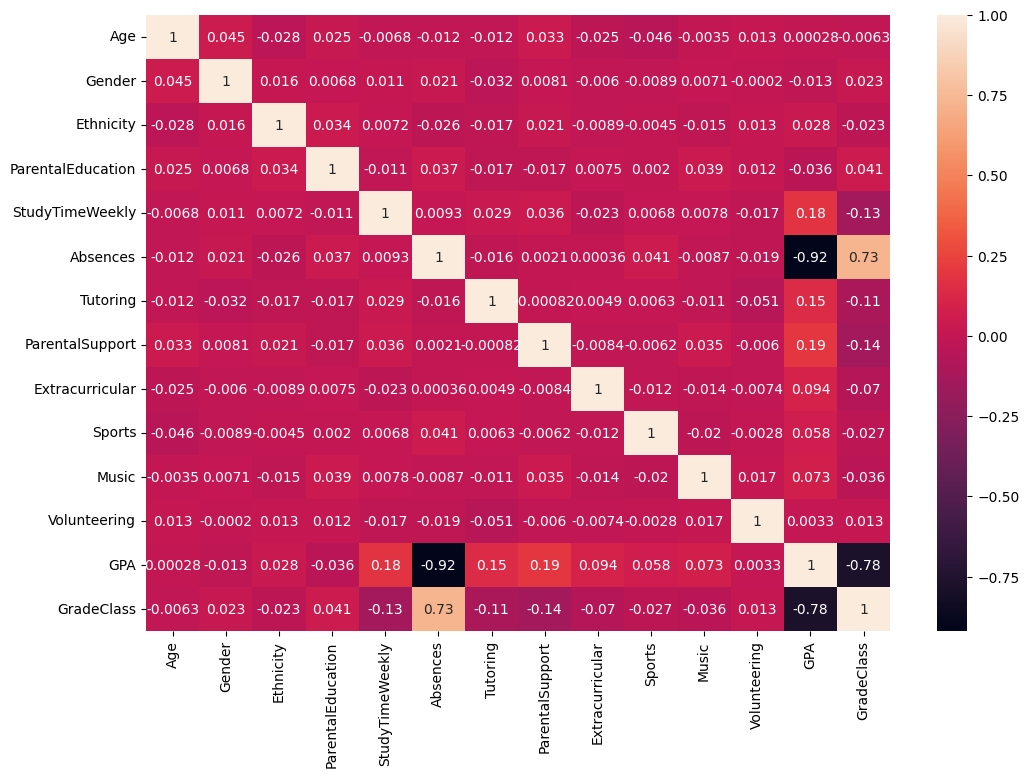

In [9]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True)

plt.show()

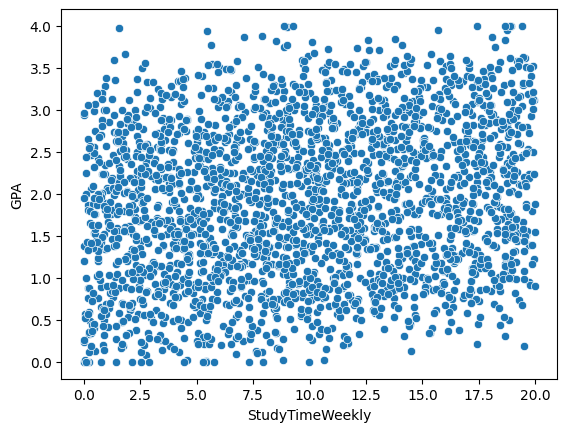

In [10]:
sns.scatterplot(
    x=df['StudyTimeWeekly'],
    y=df['GPA']
)

plt.show()

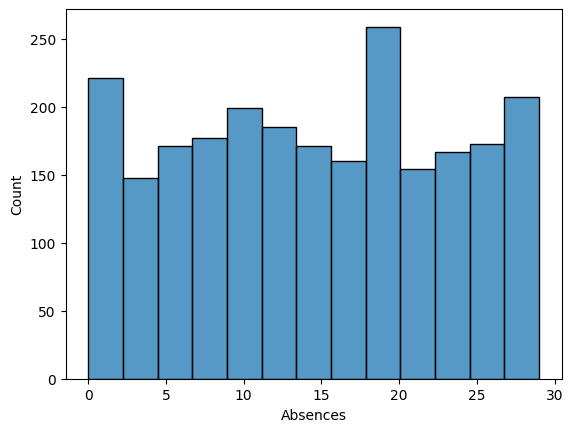

In [11]:
sns.histplot(df['Absences'])

plt.show()

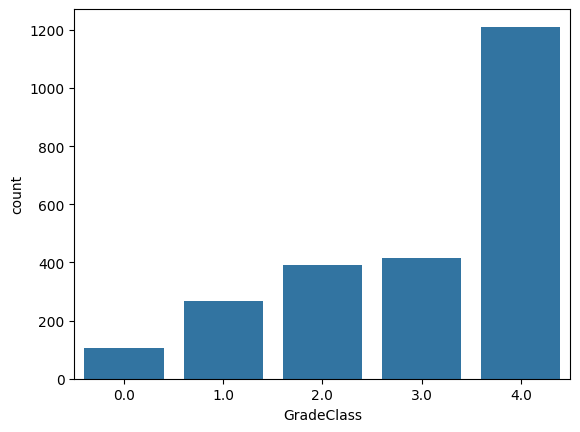

In [12]:
sns.countplot(x=df['GradeClass'])

plt.show()

In [13]:
X = df.drop("GradeClass", axis=1)

In [14]:
y = df["GradeClass"]

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
lr_model = LogisticRegression(max_iter=500)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("LR Accuracy:",
      accuracy_score(y_test, lr_pred))

LR Accuracy: 0.7369519832985386


C:\Users\vinee\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [17]:
dt_model = DecisionTreeClassifier()

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("DT Accuracy:",
      accuracy_score(y_test, dt_pred))

DT Accuracy: 0.826722338204593


In [18]:
rf_model = RandomForestClassifier()

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("RF Accuracy:",
      accuracy_score(y_test, rf_pred))

RF Accuracy: 0.9144050104384134


In [19]:
svm_model = SVC()

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

print("SVM Accuracy:",
      accuracy_score(y_test, svm_pred))

SVM Accuracy: 0.7202505219206681


In [20]:
print("Logistic Regression:",
      accuracy_score(y_test, lr_pred))

print("Decision Tree:",
      accuracy_score(y_test, dt_pred))

print("Random Forest:",
      accuracy_score(y_test, rf_pred))

print("SVM:",
      accuracy_score(y_test, svm_pred))

Logistic Regression: 0.7369519832985386
Decision Tree: 0.826722338204593
Random Forest: 0.9144050104384134
SVM: 0.7202505219206681


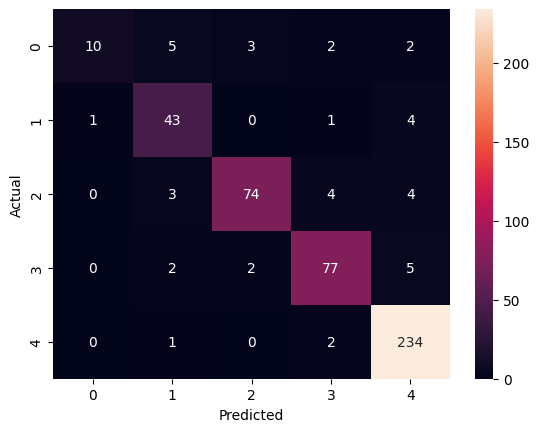

In [21]:
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm,
            annot=True,
            fmt='d')

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [22]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

         0.0       0.91      0.45      0.61        22
         1.0       0.80      0.88      0.83        49
         2.0       0.94      0.87      0.90        85
         3.0       0.90      0.90      0.90        86
         4.0       0.94      0.99      0.96       237

    accuracy                           0.91       479
   macro avg       0.90      0.82      0.84       479
weighted avg       0.92      0.91      0.91       479

